In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Found 1634 files belonging to 2 classes.
Found 350 files belonging to 2 classes.
Found 352 files belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1216s 23s/step - accuracy: 0.7901 - loss: 0.9891 - val_accuracy: 0.9371 - val_loss: 0.2358
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1115s 22s/step - accuracy: 0.9119 - loss: 0.2945 - val_accuracy: 0.9571 - val_loss: 0.1565
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1155s 21s/step - accuracy: 0.8996 - loss: 0.2824 - val_accuracy: 0.9514 - val_loss: 0.1278
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1117s 22s/step - accuracy: 0.9504 - loss: 0.1503 - val_accuracy: 0.9514 - val_loss: 0.1277
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1109s 21s/step - accuracy: 0.9590 - loss: 0.1067 - val_accuracy: 0.9571 - val_loss: 0.1220
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1105s 21s/step - accuracy: 0.9663 - loss: 0.0902 - val_accuracy: 0.9514 - val_loss: 0.1169
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1096s 21s/step - accuracy: 0.9651 - loss: 0.0980 - val_accuracy: 0.9514 - val_loss: 0.1111
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1112s 21s/step - accuracy: 0.9504 - loss: 0.1371 - val_accu

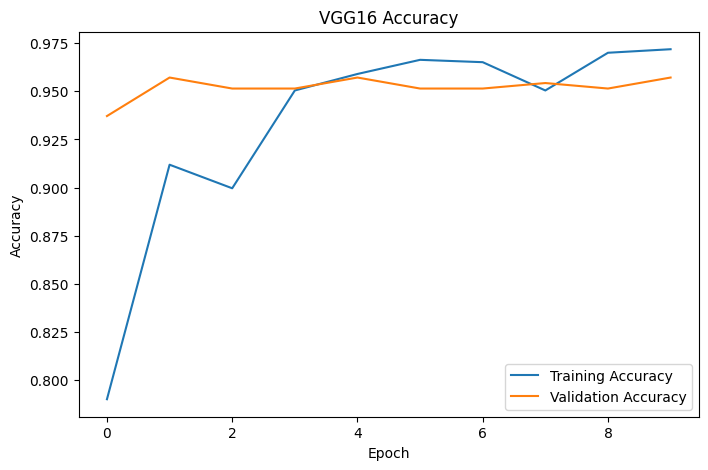

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# =====================================
# DATASET PATH
# =====================================

DATASET_PATH = "/content/drive/MyDrive/preprocessed_data_pad"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# =====================================
# LOAD DATASET
# =====================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_PATH}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =====================================
# OPTIMIZE DATA LOADING
# =====================================

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# =====================================
# LOAD VGG16
# =====================================

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# =====================================
# BUILD MODEL
# =====================================

model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

# =====================================
# COMPILE MODEL
# =====================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# =====================================
# MODEL SUMMARY
# =====================================

model.summary()

# =====================================
# TRAIN MODEL
# =====================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# =====================================
# EVALUATE MODEL
# =====================================

test_loss, test_accuracy = model.evaluate(
    test_ds
)

print(f"Test Accuracy: {test_accuracy:.4f}")

# =====================================
# SAVE MODEL
# =====================================

model.save(
    "/content/drive/MyDrive/vgg16_cataract.keras"
)

# =====================================
# PLOT RESULTS
# =====================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("VGG16 Accuracy")

plt.legend()

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 205s 19s/step
Confusion Matrix:
[[171   5]
 [  6 170]]


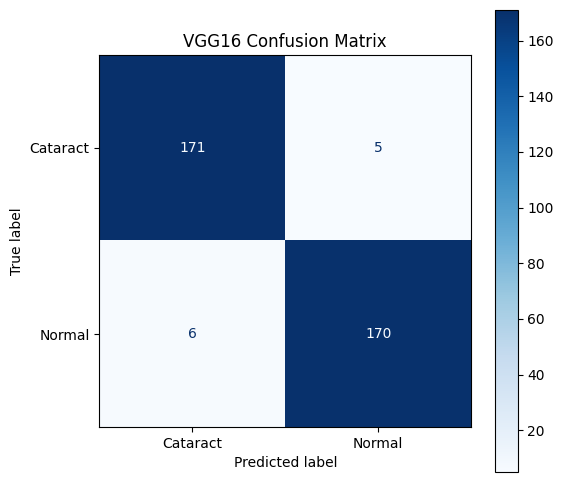


Classification Report:

              precision    recall  f1-score   support

    Cataract     0.9661    0.9716    0.9688       176
      Normal     0.9714    0.9659    0.9687       176

    accuracy                         0.9688       352
   macro avg     0.9688    0.9688    0.9687       352
weighted avg     0.9688    0.9688    0.9687       352


Accuracy: 0.9688

Average Metrics:

                  Precision   Recall  F1-Score  Support
Micro Average      0.968750  0.96875   0.96875      352
Macro Average      0.968765  0.96875   0.96875      352
Weighted Average   0.968765  0.96875   0.96875      352


In [6]:
# =====================================
# CONFUSION MATRIX + FULL METRICS
# =====================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score
)

# -------------------------------------
# GET TRUE LABELS
# -------------------------------------

y_true = np.concatenate([
    labels.numpy()
    for images, labels in test_ds
])

# -------------------------------------
# GET MODEL PREDICTIONS
# -------------------------------------

y_pred_prob = model.predict(test_ds)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# -------------------------------------
# CONFUSION MATRIX
# -------------------------------------

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# -------------------------------------
# PLOT CONFUSION MATRIX
# -------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cataract", "Normal"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues")
plt.title("VGG16 Confusion Matrix")
plt.show()

# -------------------------------------
# CLASSIFICATION REPORT
# -------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Cataract", "Normal"],
        digits=4
    )
)

# -------------------------------------
# ACCURACY
# -------------------------------------

accuracy = accuracy_score(y_true, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")

# -------------------------------------
# MICRO AVERAGE
# -------------------------------------

micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="micro"
)

# -------------------------------------
# MACRO AVERAGE
# -------------------------------------

macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro"
)

# -------------------------------------
# WEIGHTED AVERAGE
# -------------------------------------

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

# -------------------------------------
# DISPLAY SUMMARY TABLE
# -------------------------------------

summary = pd.DataFrame({
    "Precision": [
        micro_precision,
        macro_precision,
        weighted_precision
    ],
    "Recall": [
        micro_recall,
        macro_recall,
        weighted_recall
    ],
    "F1-Score": [
        micro_f1,
        macro_f1,
        weighted_f1
    ],
    "Support": [
        len(y_true),
        len(y_true),
        len(y_true)
    ]
},
index=[
    "Micro Average",
    "Macro Average",
    "Weighted Average"
])

print("\nAverage Metrics:\n")
print(summary)